In [36]:
import pandas as pd

train = pd.read_csv("../data/raw/train.csv")
test = pd.read_csv("../data/raw/test.csv")

In [37]:
X = train.drop("SalePrice", axis=1)
y = train["SalePrice"]

In [38]:
print("X shape:", X.shape)
print("y shape:", y.shape)
print("test shape:", test.shape)

X shape: (1460, 80)
y shape: (1460,)
test shape: (1459, 80)


In [39]:
missing_X = pd.DataFrame({
    "Missing Count": X.isnull().sum(),
    "Missing Percent": (X.isnull().sum() / len(X)) * 100
})

missing_X = missing_X[missing_X["Missing Count"] > 0]
missing_X = missing_X.sort_values(by="Missing Count", ascending=False)

missing_X

,Missing Count,Missing Percent
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945


In [40]:
missing_test = pd.DataFrame({
    "Missing Count": test.isnull().sum(),
    "Missing Percent": (test.isnull().sum() / len(test)) * 100
})

missing_test = missing_test[missing_test["Missing Count"] > 0]
missing_test = missing_test.sort_values(by="Missing Count", ascending=False)

missing_test

,Missing Count,Missing Percent
PoolQC,1456,99.794380
MiscFeature,1408,96.504455
Alley,1352,92.666210
Fence,1169,80.123372
MasVnrType,894,61.274846
FireplaceQu,730,50.034270
LotFrontage,227,15.558602
GarageQual,78,5.346127
GarageCond,78,5.346127
GarageYrBlt,78,5.346127


## Missing Value Analysis

The missing-value analysis shows that several columns have a very high percentage of missing values. However, in this dataset, many missing values are meaningful and do not necessarily represent data errors.

For example, `PoolQC` has 1453 missing values, which likely means that most houses do not have a pool. Similarly, missing values in `MiscFeature`, `Alley`, `Fence`, and `FireplaceQu` likely indicate that the house does not have that specific feature.

Garage-related columns such as `GarageType`, `GarageFinish`, `GarageQual`, and `GarageCond` have 81 missing values. These missing values probably indicate houses with no garage. The numerical garage feature `GarageYrBlt` is also missing for the same houses.

Basement-related columns such as `BsmtExposure`, `BsmtFinType2`, `BsmtQual`, `BsmtCond`, and `BsmtFinType1` also contain missing values. These likely indicate houses with no basement.

Some missing values appear to be real missing information rather than absence of a feature. For example, `LotFrontage` has 259 missing values and should probably be imputed using a numerical strategy such as the median. `Electrical` has only one missing value and can likely be filled using the most frequent category.

Overall, missing values should be handled based on their meaning. Categorical missing values that indicate absence of a feature can be filled with `"None"`, while numerical missing values can be filled with `0` when absence is meaningful or with the median when the value is truly unknown.

## Test Set Missing Value Analysis

The test set contains missing values in many of the same columns as the training set, such as `PoolQC`, `MiscFeature`, `Alley`, `Fence`, `FireplaceQu`, garage-related columns, basement-related columns, `LotFrontage`, `MasVnrType`, and `MasVnrArea`.

However, the test set also contains missing values in additional columns such as `MSZoning`, `Functional`, `Utilities`, `Exterior1st`, `Exterior2nd`, `KitchenQual`, `GarageCars`, `GarageArea`, and `SaleType`.

This is important because preprocessing decisions must work for both the training and test datasets. Some missing values represent the absence of a feature, such as no garage, no basement, no pool, or no alley access. Other missing values are real missing information and should be filled using an appropriate imputation strategy.

For categorical columns with real missing values, the most frequent category can be used. For numerical columns with real missing values, the median is usually a safe choice. For numerical columns where missing means the feature does not exist, such as garage or basement measurements, filling with `0` is more meaningful.

In [41]:
none_cols = [
    "PoolQC",
    "MiscFeature",
    "Alley",
    "Fence",
    "FireplaceQu",
    "GarageType",
    "GarageFinish",
    "GarageQual",
    "GarageCond",
    "BsmtQual",
    "BsmtCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2",
    "MasVnrType"
]
for col in none_cols:
    X[col] = X[col].fillna("None")
    test[col] = test[col].fillna("None")

    
X[none_cols].isnull().sum()
test[none_cols].isnull().sum()

PoolQC          0
MiscFeature     0
Alley           0
Fence           0
FireplaceQu     0
GarageType      0
GarageFinish    0
GarageQual      0
GarageCond      0
BsmtQual        0
BsmtCond        0
BsmtExposure    0
BsmtFinType1    0
BsmtFinType2    0
MasVnrType      0
dtype: int64

## Handling Categorical Missing Values Meaning “Not Present”

Some categorical missing values do not represent errors. Instead, they indicate that the house does not have that feature. For example, a missing value in `PoolQC` means the house likely has no pool, and a missing value in garage-related columns means the house likely has no garage.

For these columns, missing values were replaced with `"None"` in both the training features and the test set. This preserves useful information instead of deleting the columns or treating the values as unknown.

In [42]:
zero_cols = [
    "GarageYrBlt",
    "GarageCars",
    "GarageArea",
    "BsmtFinSF1",
    "BsmtFinSF2",
    "BsmtUnfSF",
    "TotalBsmtSF",
    "BsmtFullBath",
    "BsmtHalfBath",
    "MasVnrArea"
]
for col in zero_cols:
    X[col] = X[col].fillna(0)
    test[col] = test[col].fillna(0)


X[zero_cols].isnull().sum()
test[zero_cols].isnull().sum()

GarageYrBlt     0
GarageCars      0
GarageArea      0
BsmtFinSF1      0
BsmtFinSF2      0
BsmtUnfSF       0
TotalBsmtSF     0
BsmtFullBath    0
BsmtHalfBath    0
MasVnrArea      0
dtype: int64

## Handling Numerical Missing Values Meaning “Not Present”

Some numerical missing values represent the absence of a feature rather than unknown information. For example, missing garage area or garage capacity likely means the house has no garage. Similarly, missing basement square footage or basement bathrooms likely means the house has no basement.

For these columns, missing values were replaced with `0` in both the training features and the test set. This keeps the meaning of absence clear and allows the model to interpret these features numerically.

In [43]:
real_num_cols = [
    "LotFrontage"
]
for col in real_num_cols:
    median_value = X[col].median()
    X[col] = X[col].fillna(median_value)
    test[col] = test[col].fillna(median_value)

X[real_num_cols].isnull().sum()
test[real_num_cols].isnull().sum()

LotFrontage    0
dtype: int64

In [44]:
real_cat_cols = [
    "Electrical",
    "MSZoning",
    "Functional",
    "Utilities",
    "Exterior1st",
    "Exterior2nd",
    "KitchenQual",
    "SaleType"
] 
for col in real_cat_cols:
    mode_value=X[col].mode()[0]
    X[col] = X[col].fillna(mode_value)
    test[col] = test[col].fillna(mode_value)
X[real_cat_cols].isnull().sum()
test[real_cat_cols].isnull().sum()

Electrical     0
MSZoning       0
Functional     0
Utilities      0
Exterior1st    0
Exterior2nd    0
KitchenQual    0
SaleType       0
dtype: int64

## Handling Real Missing Values

After handling missing values that represented the absence of a feature, the remaining missing values were treated as real missing information.

For numerical columns such as `LotFrontage`, missing values were filled using the median value from the training data. The median was used because it is less affected by outliers than the mean.

For categorical columns such as `Electrical`, `MSZoning`, `Functional`, `Utilities`, `Exterior1st`, `Exterior2nd`, `KitchenQual`, and `SaleType`, missing values were filled using the most frequent category from the training data.

The imputation values were calculated from the training data and then applied to both the training features and the test set. This prevents the test set from influencing preprocessing decisions.

In [45]:
quality_map = {
    "None": 0,
    "Po": 1,
    "Fa": 2,
    "TA": 3,
    "Gd": 4,
    "Ex": 5
}

quality_cols = [
    "ExterQual",
    "ExterCond",
    "BsmtQual",
    "BsmtCond",
    "HeatingQC",
    "KitchenQual",
    "FireplaceQu",
    "GarageQual",
    "GarageCond",
    "PoolQC"
]

for col in quality_cols:
    X[col] = X[col].map(quality_map)
    test[col] = test[col].map(quality_map)

bsmt_exposure_map = {
    "None": 0,
    "No": 1,
    "Mn": 2,
    "Av": 3,
    "Gd": 4
}

for col in ["BsmtExposure"]:
    X[col] = X[col].map(bsmt_exposure_map)
    test[col] = test[col].map(bsmt_exposure_map)

bsmt_fin_map = {
    "None": 0,
    "Unf": 1,
    "LwQ": 2,
    "Rec": 3,
    "BLQ": 4,
    "ALQ": 5,
    "GLQ": 6
}

for col in ["BsmtFinType1", "BsmtFinType2"]:
    X[col] = X[col].map(bsmt_fin_map)
    test[col] = test[col].map(bsmt_fin_map)

garage_finish_map = {
    "None": 0,
    "Unf": 1,
    "RFn": 2,
    "Fin": 3
}

X["GarageFinish"] = X["GarageFinish"].map(garage_finish_map)
test["GarageFinish"] = test["GarageFinish"].map(garage_finish_map)

In [46]:
X_encoded = pd.get_dummies(X)
test_encoded = pd.get_dummies(test)
X_encoded, test_encoded = X_encoded.align(
    test_encoded,
    join="left",
    axis=1,
    fill_value=0
)
print("X encoded shape:", X_encoded.shape)
print("Test encoded shape:", test_encoded.shape)
X_encoded.select_dtypes(include=["object"]).columns
test_encoded.select_dtypes(include=["object"]).columns

X encoded shape: (1460, 244)
Test encoded shape: (1459, 244)


Index([], dtype='str')

## Categorical Encoding

Categorical variables were encoded so that machine learning models can read them.

Ordinal categorical variables, such as quality and condition features, were manually mapped to numerical values because their categories have a natural order. For example, `Ex` is better than `Gd`, which is better than `TA`, `Fa`, and `Po`.

Nominal categorical variables, such as `Neighborhood`, `GarageType`, and `SaleCondition`, were one-hot encoded because they do not have a natural order.

After encoding, the training and test datasets were aligned to make sure they contain the same final feature columns.

## Categorical Encoding

Categorical variables were encoded so that machine learning models can read them.

Ordinal categorical variables, such as quality and condition features, were manually mapped to numerical values because their categories have a natural order. For example, `Ex` is better than `Gd`, which is better than `TA`, `Fa`, and `Po`.

Nominal categorical variables, such as `Neighborhood`, `GarageType`, and `SaleCondition`, were one-hot encoded because they do not have a natural order.

After encoding, the training and test datasets were aligned to make sure they contain the same final feature columns.

In [48]:
print("SalePrice skewness:", y.skew())

SalePrice skewness: 1.8828757597682129


In [49]:
numeric_features = X.select_dtypes(include=["int64", "float64"])

skewness = numeric_features.skew().sort_values(ascending=False)

skewness.head(20)





MiscVal          24.476794
PoolQC           15.958567
PoolArea         14.828374
LotArea          12.207688
3SsnPorch        10.304342
LowQualFinSF      9.011341
KitchenAbvGr      4.488397
BsmtFinSF2        4.255261
ScreenPorch       4.122214
BsmtHalfBath      4.103403
BsmtFinType2      3.296996
EnclosedPorch     3.089872
MasVnrArea        2.677616
LotFrontage       2.409147
OpenPorchSF       2.364342
BsmtFinSF1        1.685503
WoodDeckSF        1.541376
TotalBsmtSF       1.524255
MSSubClass        1.407657
ExterCond         1.397219
dtype: float64

In [50]:
high_skew = skewness[skewness > 1]

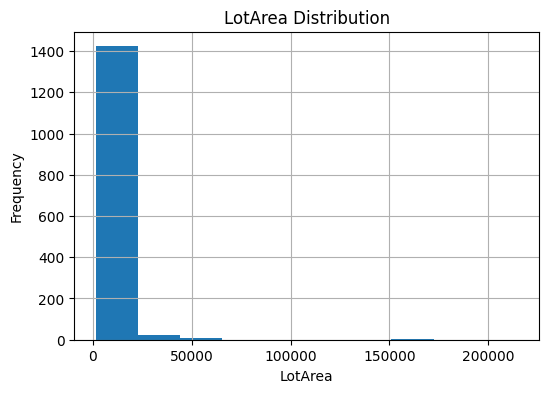

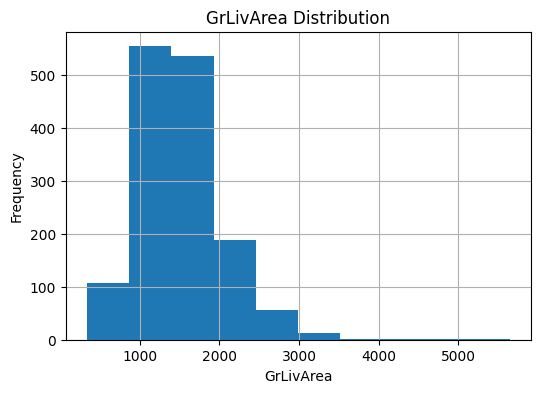

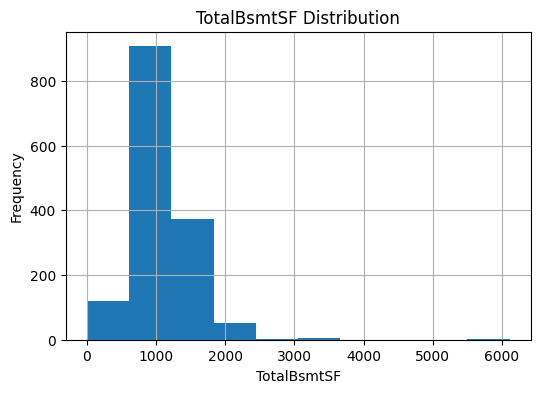

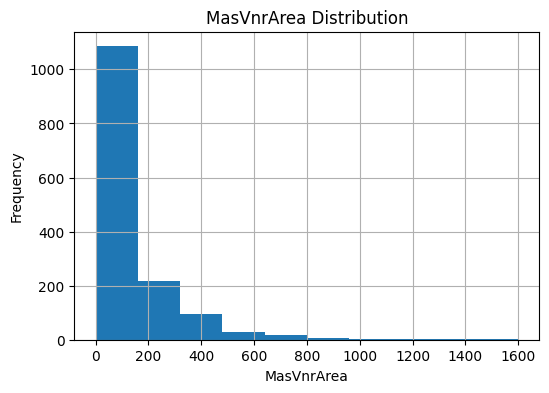

In [51]:
features_to_plot = ["LotArea", "GrLivArea", "TotalBsmtSF", "MasVnrArea"]

for feature in features_to_plot:
    plt.figure(figsize=(6, 4))
    X[feature].hist()
    plt.title(f"{feature} Distribution")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.show()

## Skewness Analysis

The target variable `SalePrice` is right-skewed, meaning that most houses have moderate prices while a smaller number of houses have very high prices.

Several numerical features are also right-skewed. This means that most houses have relatively small or zero values for these features, while a few houses have very large values.

Highly skewed features may benefit from a log transformation later, especially features such as `LotArea`, `GrLivArea`, `TotalBsmtSF`, and `MasVnrArea`. However, transformation should be applied carefully, especially for variables that contain many zero values.

## Skewness Results

Several numerical features are highly right-skewed. The most skewed features include:

- `MiscVal`: 24.48
- `PoolArea`: 14.83
- `LotArea`: 12.21
- `3SsnPorch`: 10.30
- `LowQualFinSF`: 9.01
- `KitchenAbvGr`: 4.49
- `BsmtFinSF2`: 4.26
- `ScreenPorch`: 4.12
- `BsmtHalfBath`: 4.10
- `EnclosedPorch`: 3.09
- `MasVnrArea`: 2.68
- `LotFrontage`: 2.41
- `OpenPorchSF`: 2.36
- `BsmtFinSF1`: 1.69
- `WoodDeckSF`: 1.54
- `TotalBsmtSF`: 1.52
- `1stFlrSF`: 1.38
- `GrLivArea`: 1.37

These values show that many features have most observations concentrated at small values, while a few houses have very large values.

Some of these features, such as `MiscVal`, `PoolArea`, `3SsnPorch`, and `LowQualFinSF`, are highly skewed because most houses have a value of 0, while only a few houses have non-zero values.

Features such as `LotArea`, `GrLivArea`, `TotalBsmtSF`, `1stFlrSF`, and `MasVnrArea` may benefit from a log transformation because they represent continuous size-related variables and are right-skewed.

However, features with many zeros should be transformed carefully using `log1p`, because normal log transformation cannot be applied directly to zero values.

In [52]:
import numpy as np
y_log = np.log1p(y)
print("Original SalePrice skewness:", y.skew())
print("Log-transformed SalePrice skewness:", y_log.skew())
log_features = [
    "LotArea",
    "GrLivArea",
    "TotalBsmtSF",
    "1stFlrSF",
    "MasVnrArea"
]
for col in log_features:
    X[col] = np.log1p(X[col])
    test[col] = np.log1p(test[col])

X[log_features].skew().sort_values(ascending=False)

Original SalePrice skewness: 1.8828757597682129
Log-transformed SalePrice skewness: 0.12134661989685333


MasVnrArea     0.503532
1stFlrSF       0.080114
GrLivArea     -0.006140
LotArea       -0.137404
TotalBsmtSF   -5.154670
dtype: float64

In [53]:
X_encoded = pd.get_dummies(X)
test_encoded = pd.get_dummies(test)

X_encoded, test_encoded = X_encoded.align(
    test_encoded,
    join="left",
    axis=1,
    fill_value=0
)

In [54]:
print("X encoded shape:", X_encoded.shape)
print("Test encoded shape:", test_encoded.shape)

X encoded shape: (1460, 244)
Test encoded shape: (1459, 244)


## Log Transformation

The target variable `SalePrice` was right-skewed, meaning that most houses had moderate prices while a smaller number of houses had very high prices. To reduce this skewness, a `log1p` transformation was applied to the target variable.

Selected right-skewed numerical features were also transformed using `log1p`, including `LotArea`, `GrLivArea`, `TotalBsmtSF`, `1stFlrSF`, and `MasVnrArea`.

The `log1p` function was used instead of a normal log transformation because some variables can contain zero values. `log1p` calculates `log(1 + x)`, which safely handles zero values.

After transforming numerical features, the encoded training and test datasets were recreated so that the final model-ready data includes the transformed feature values.

In [55]:
for df in [X, test]:
    df["TotalSF"] = df["TotalBsmtSF"] + df["1stFlrSF"] + df["2ndFlrSF"]

    df["TotalBath"] = (
        df["FullBath"]
        + 0.5 * df["HalfBath"]
        + df["BsmtFullBath"]
        + 0.5 * df["BsmtHalfBath"]
    )

    df["HouseAge"] = df["YrSold"] - df["YearBuilt"]

    df["RemodAge"] = df["YrSold"] - df["YearRemodAdd"]

    df["HasGarage"] = (df["GarageArea"] > 0).astype(int)

    df["HasBasement"] = (df["TotalBsmtSF"] > 0).astype(int)

    df["HasPool"] = (df["PoolArea"] > 0).astype(int)

In [56]:
new_features = [
    "TotalSF",
    "TotalBath",
    "HouseAge",
    "RemodAge",
    "HasGarage",
    "HasBasement",
    "HasPool"
]

X[new_features].head()

,TotalSF,TotalBath,HouseAge,RemodAge,HasGarage,HasBasement,HasPool
0,867.506876,3.5,5,5,1,1,0
1,14.282490,2.5,31,31,1,1,0
2,879.650920,3.5,7,6,1,1,0
3,769.498378,2.0,91,36,1,1,0
4,1067.088066,3.5,8,8,1,1,0


In [57]:
test[new_features].head()

,TotalSF,TotalBath,HouseAge,RemodAge,HasGarage,HasBasement,HasPool
0,13.582381,1.0,49,49,1,1,0
1,14.385868,1.5,52,52,1,1,0
2,714.668217,2.5,13,12,1,1,0
3,691.663907,2.5,12,12,1,1,0
4,14.310793,2.0,18,18,1,1,0


In [58]:
X_encoded = pd.get_dummies(X)
test_encoded = pd.get_dummies(test)

X_encoded, test_encoded = X_encoded.align(
    test_encoded,
    join="left",
    axis=1,
    fill_value=0
)

In [59]:
print("X encoded shape:", X_encoded.shape)
print("Test encoded shape:", test_encoded.shape)

X encoded shape: (1460, 251)
Test encoded shape: (1459, 251)


## Feature Engineering

Several new features were created to provide the model with more meaningful information.

`TotalSF` was created by combining basement, first-floor, and second-floor square footage. This gives a broader measure of the total size of the house.

`TotalBath` was created by combining full and half bathrooms, including basement bathrooms. Half bathrooms were counted as 0.5 because they provide less value than full bathrooms.

`HouseAge` was created using the difference between the year the house was sold and the year it was built. This gives the model a clearer measure of how old the house was at the time of sale.

`RemodAge` was created using the difference between the year the house was sold and the year it was remodeled. This helps represent how recent the remodeling was.

Binary features such as `HasGarage`, `HasBasement`, and `HasPool` were also created to indicate whether the house has these features or not.

The same feature engineering steps were applied to both the training features and the test set to keep them consistent.

In [60]:
print("Missing values in X_encoded:", X_encoded.isnull().sum().sum())
print("Missing values in test_encoded:", test_encoded.isnull().sum().sum())

Missing values in X_encoded: 0
Missing values in test_encoded: 0


## Final Preprocessing Check

After handling missing values, encoding categorical variables, applying log transformation, and creating new features, the final training and test feature sets were checked.

`X_encoded` and `test_encoded` have the same number of columns, which means they are aligned correctly and ready for modeling.

Both datasets contain no missing values, and no text/object columns remain. This means all features are now numerical and can be used by machine learning models.

The transformed target variable `y_log` is also ready for modeling. It has no missing values and has lower skewness than the original `SalePrice`.

In [61]:
import os

os.makedirs("../data/processed", exist_ok=True)

X_encoded.to_csv("../data/processed/X_train_processed.csv", index=False)
test_encoded.to_csv("../data/processed/X_test_processed.csv", index=False)
y_log.to_csv("../data/processed/y_train_log.csv", index=False)

In [62]:
os.listdir("../data/processed")

['X_test_processed.csv', 'X_train_processed.csv', 'y_train_log.csv']